In [1]:
"""A short example of how to run GOFHER"""

'A short example of how to run GOFHER'

## Import:
Import the following functions/ classes:

In [2]:
from pathlib import Path

from gofher.galaxy import Galaxy
from gofher.sparcfire import gofher_params_from_sparcfire_csv

## Paths:
Set the specific paths to the fits data and galaxy.csv

We will also create helper functions to get the full path for the fits/ galaxy.csv

In [3]:
#IMPORTANT: Make sure these folder/file names reflect test file structure:
TEST_GALAXY_DIR = "NGC2347_SDSS_psf4_background_256"
TEST_SPARCFIRE_DIR = "sparcfire_r_band_output"
TEST_FITS_DIR = "fits"
TEST_CSV_FILE_NAME = "NGC2347_r.csv"

def _get_test_csv_path() -> str:
    p = Path("..").resolve()
    return str(p.joinpath("tests", "data", TEST_GALAXY_DIR, TEST_SPARCFIRE_DIR, TEST_CSV_FILE_NAME))

def _get_test_fits_path(the_band) -> str:
    """Helper function to get path to test fits file"""
    fits_file_name = f"NGC2347_{the_band}.fits"

    p = Path("..").resolve()
    return str(p.joinpath("tests", "data", TEST_GALAXY_DIR, TEST_FITS_DIR, fits_file_name))

## Set the Run specific parameters:
* `bluer_to_redder_bands` is a list of the fits wavebands ordered bluest light first to reddest light last
* `sparcfire_bulge_disk_f` is the number in range `[0,1]` that specifies the scale of the galaxy ellipse mask to use. When `sparcfire_bulge_disk_f=0` the ellipse uses the bulge major axis, when `sparcfire_bulge_disk_f=1` the ellipse uses the disk major axis, otherwise interpolates between bulge and disk major axis

In [4]:
BLUER_TO_REDDER_BANDS = ['g','r','i','z']
SPARCFIRE_BULGE_DISK_F = 0.5

## Running Gofher:

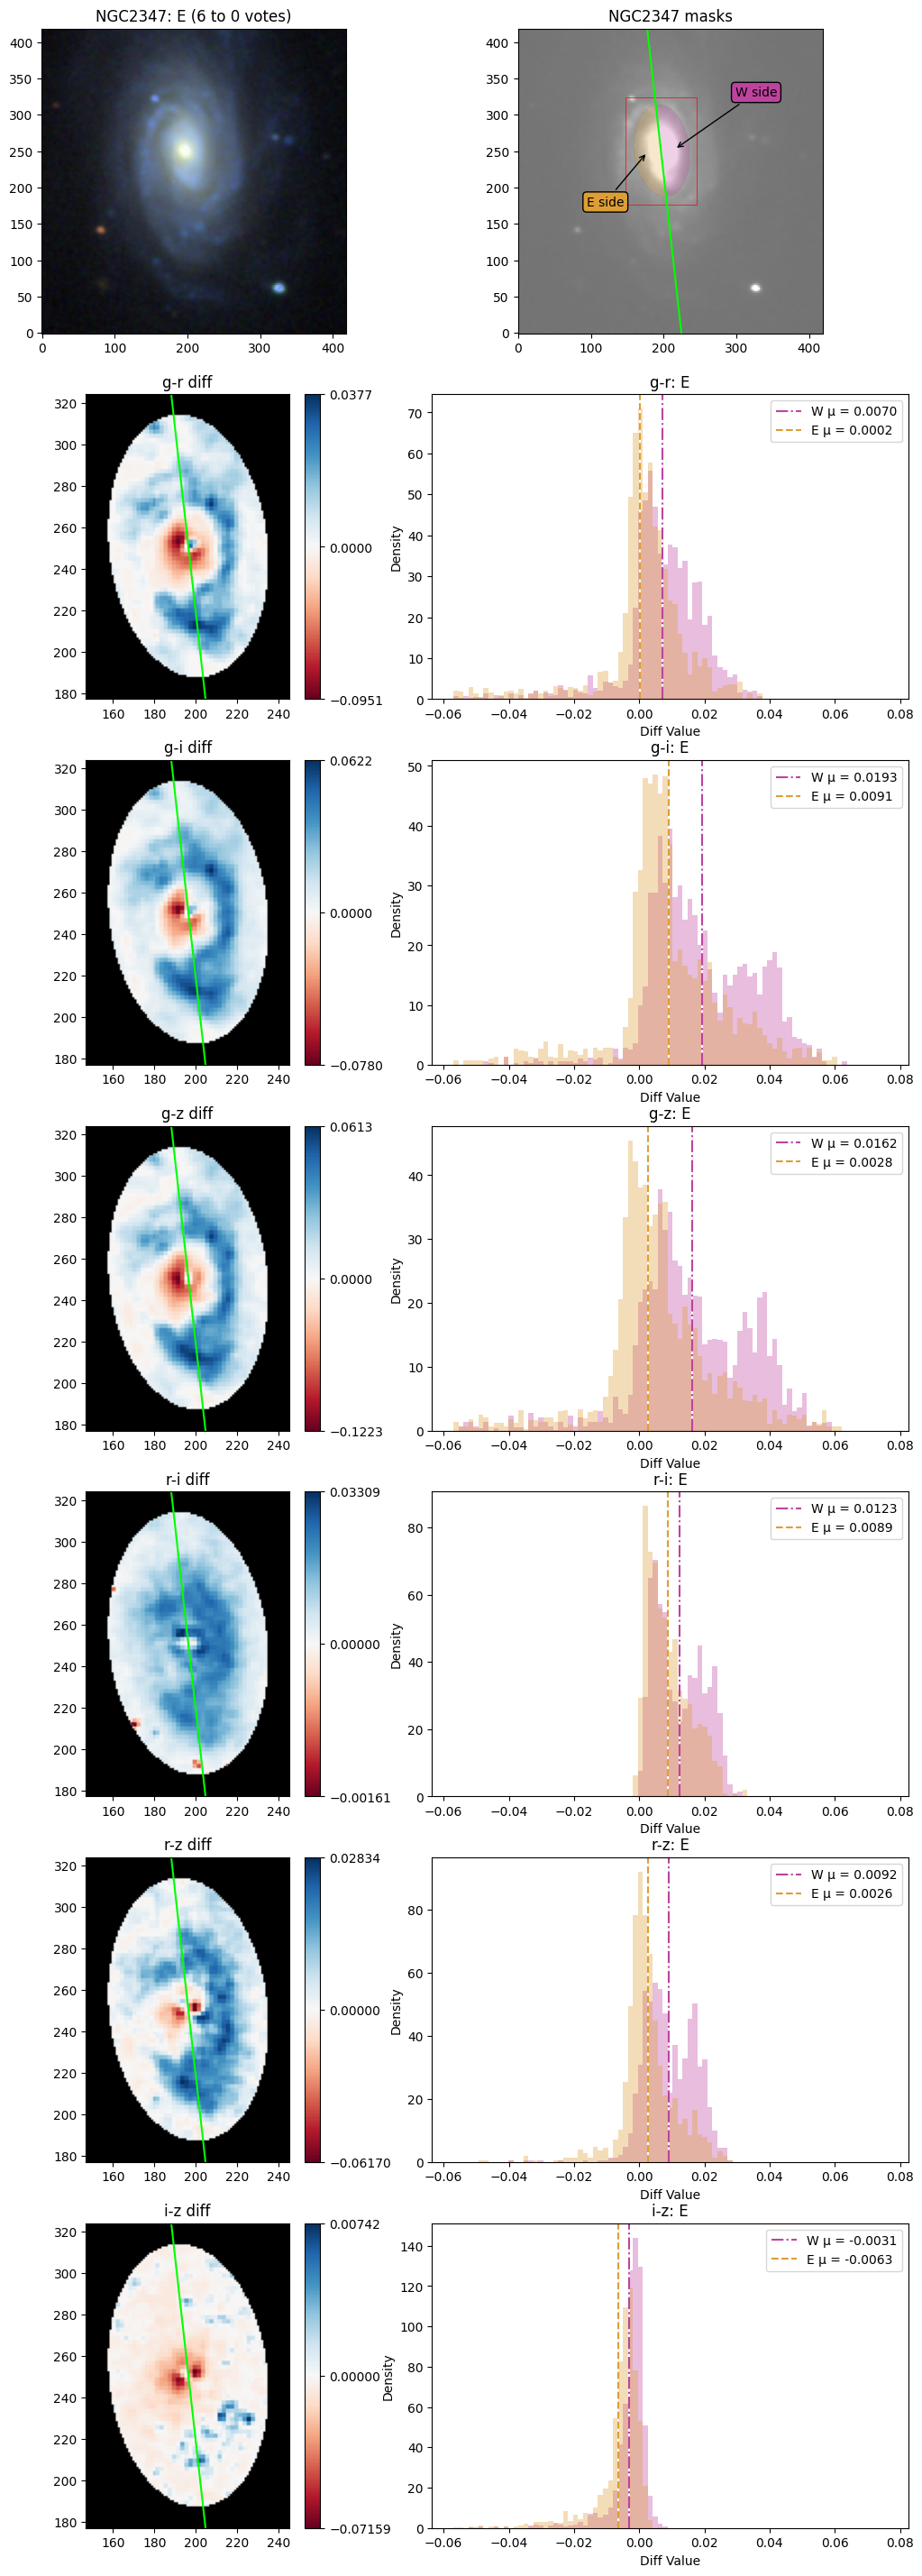

In [5]:
# Get the GOFHER parameters from the SparcFiRe galaxy.csv:
gofher_param = gofher_params_from_sparcfire_csv(_get_test_csv_path())[0]

# Create a Galaxy and add all wavebands to it:
the_galaxy = Galaxy(gofher_param)

for band in BLUER_TO_REDDER_BANDS:
    the_galaxy.construct_galaxy_band_from_fits(band,_get_test_fits_path(band))

# Run GOFHER on the galaxy:
the_galaxy.run(bluer_to_redder_bands=BLUER_TO_REDDER_BANDS,
               sparcfire_bulge_disk_f=SPARCFIRE_BULGE_DISK_F,
               area_to_consider=None,
               fail_silently_on_missing_band=False)

# Plot a figure visualization GOFHER's output:
the_galaxy.plot_figure()